# Linear Regression Diagnostics

**Flow:** fit → residual plot → normality check → correlated-feature warning.

Residual patterns help identify nonlinearity and unequal variance. Normal residuals support small-sample inference; they are not required for OLS coefficients to be unbiased.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

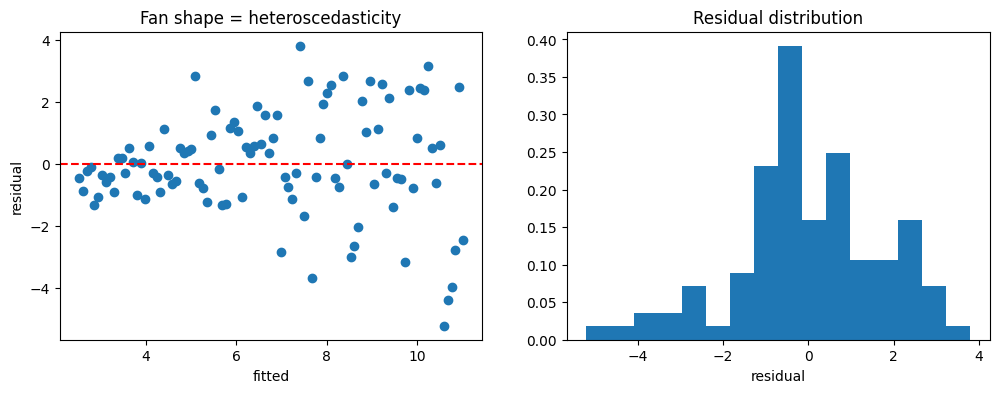

In [2]:
x=np.linspace(0,10,100); y=2+x+rng.normal(0,.3+x*.35,100); m=LinearRegression().fit(x[:,None],y); fitted=m.predict(x[:,None]); residual=y-fitted; fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].scatter(fitted,residual); ax[0].axhline(0,color='r',ls='--'); ax[0].set(title='Fan shape = heteroscedasticity',xlabel='fitted',ylabel='residual'); ax[1].hist(residual,bins=16,density=True); ax[1].set(title='Residual distribution',xlabel='residual'); plt.show()

Multicollinearity can make individual OLS coefficients unstable. It does not automatically make predictions poor; Ridge can be a useful predictive remedy.

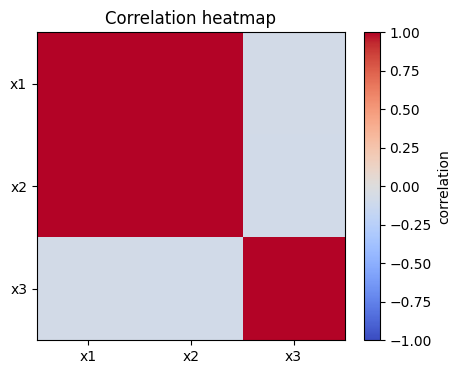

In [3]:
a=rng.normal(size=120); X=np.c_[a,a+rng.normal(0,.05,120),rng.normal(size=120)]; corr=np.corrcoef(X,rowvar=False); plt.figure(figsize=(5,4)); plt.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm'); plt.colorbar(label='correlation'); plt.xticks(range(3),['x1','x2','x3']); plt.yticks(range(3),['x1','x2','x3']); plt.title('Correlation heatmap'); plt.show()